In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Path to dataset files: /kaggle/input/medicaltranscriptions


In [9]:
import os
print(os.listdir(path))

['mtsamples.csv', '.nfs00000000a9ac2dd900000050']


In [10]:
import pandas as pd
new_p=os.path.join(path,'mtsamples.csv')

df=pd.read_csv(new_p)
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [11]:
df.columns



Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')

##Medical Text Analysis

In [12]:
print("Total Reports:", len(df))

Total Reports: 4999


In [13]:
specialty_counts = (
    df['medical_specialty']
    .value_counts()
)

print(specialty_counts)

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Dentistry                          27
Cosmetic / Plastic Surgery      

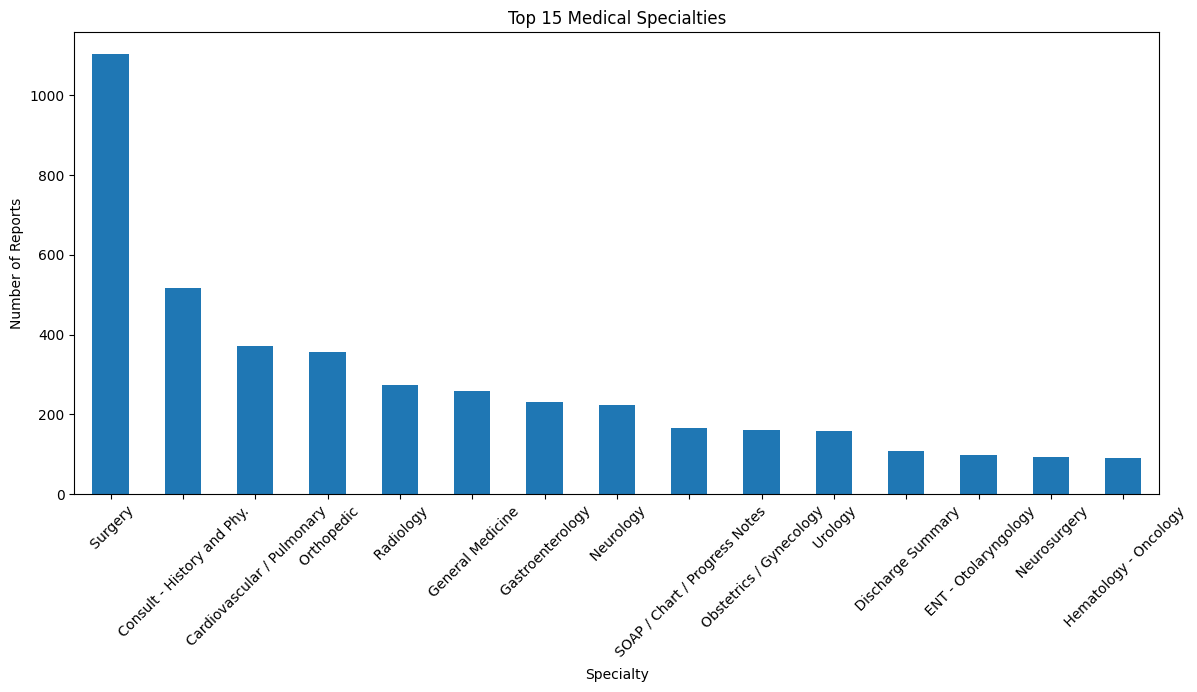

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14,6))

specialty_counts.head(15).plot(
    kind='bar'
)

plt.title(
    "Top 15 Medical Specialties"
)

plt.xlabel("Specialty")
plt.ylabel("Number of Reports")

plt.xticks(rotation=45)

plt.show()

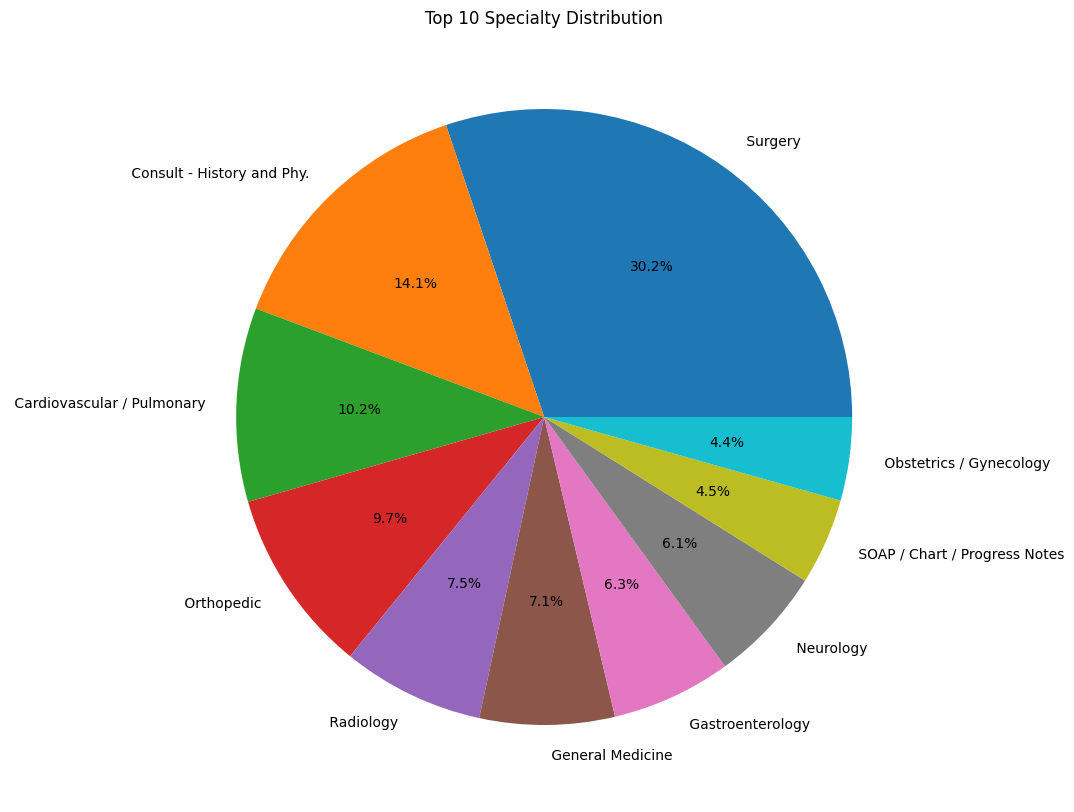

In [15]:
plt.figure(figsize=(10,10))

specialty_counts.head(10).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title(
    "Top 10 Specialty Distribution"
)

plt.show()

In [16]:
df['report_length'] = (
    df['transcription']
    .fillna("")
    .apply(lambda x: len(x.split()))
)

In [17]:
print(
    df['report_length']
    .describe()
)

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: report_length, dtype: float64


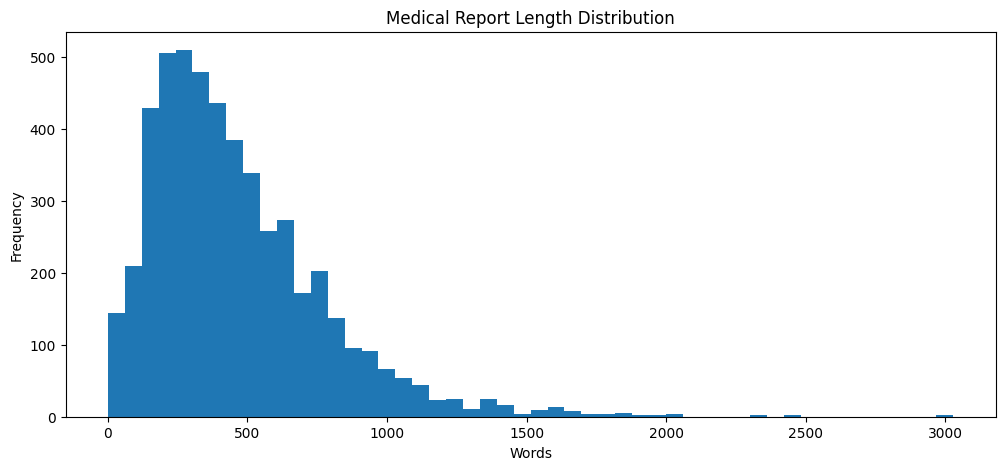

In [18]:
plt.figure(figsize=(12,5))

plt.hist(
    df['report_length'],
    bins=50
)

plt.title(
    "Medical Report Length Distribution"
)

plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [19]:
all_text = " ".join(
    df['transcription']
    .fillna("")
    .astype(str)
)

import re

all_text = all_text.lower()

words = re.findall(
    r'\b[a-z]+\b',
    all_text
)

from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(
    stopwords.words('english')
)

filtered_words = [
    word
    for word in words
    if word not in stop_words
]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [20]:
from collections import Counter

word_freq = Counter(
    filtered_words
)

print(
    word_freq.most_common(30)
)

[('patient', 24208), ('right', 11587), ('left', 11258), ('history', 9509), ('normal', 7526), ('procedure', 7463), ('placed', 7028), ('well', 6611), ('pain', 5976), ('noted', 4348), ('also', 4337), ('time', 4287), ('using', 4123), ('mg', 4087), ('blood', 3956), ('performed', 3953), ('skin', 3798), ('without', 3732), ('anesthesia', 3707), ('incision', 3601), ('x', 3585), ('used', 3554), ('removed', 3532), ('year', 3504), ('room', 3502), ('old', 3463), ('diagnosis', 3212), ('general', 3064), ('artery', 3027), ('anterior', 2932)]


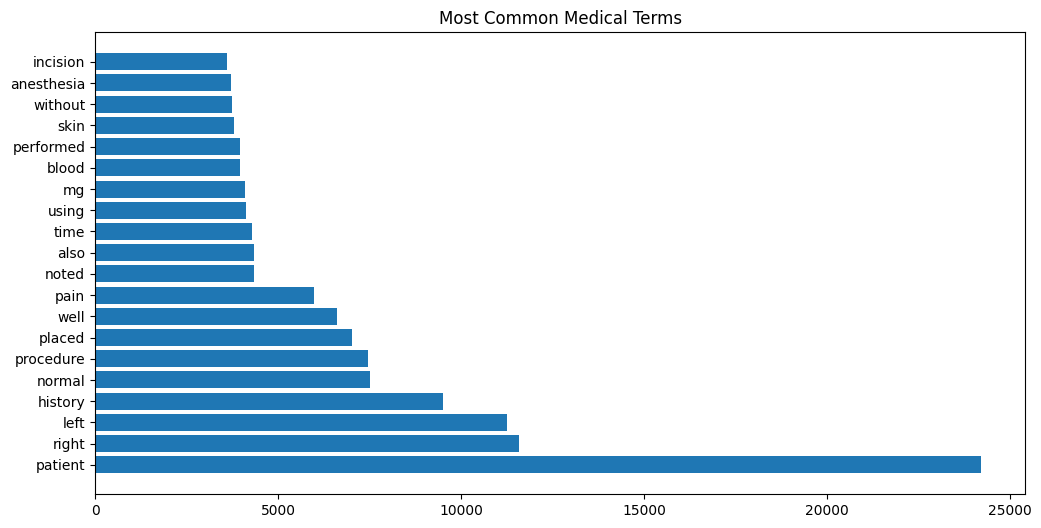

In [21]:
top_words = word_freq.most_common(20)

terms = [x[0] for x in top_words]
freqs = [x[1] for x in top_words]

plt.figure(figsize=(12,6))

plt.barh(
    terms,
    freqs
)

plt.title(
    "Most Common Medical Terms"
)

plt.show()

In [22]:
vocab_df = pd.DataFrame(
    word_freq.items(),
    columns=[
        "Medical_Term",
        "Frequency"
    ]
)

vocab_df = vocab_df.sort_values(
    by="Frequency",
    ascending=False
)

print(vocab_df.head(20))

     Medical_Term  Frequency
545       patient      24208
135         right      11587
436          left      11258
95        history       9509
440        normal       7526
526     procedure       7463
549        placed       7028
34           well       6611
123          pain       5976
736         noted       4348
24           also       4337
19           time       4287
28          using       4123
1155           mg       4087
57          blood       3956
432     performed       3953
205          skin       3798
63        without       3732
530    anesthesia       3707
571      incision       3601


In [23]:
vocab_df.to_csv(
    "medical_dictionary.csv",
    index=False
)

##Medical Vocabulary Builder

In [24]:
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords

In [25]:
df = df.dropna(
    subset=[
        'transcription',
        'medical_specialty'
    ]
)

stop_words = set(
    stopwords.words('english')
)

In [26]:
all_text = " ".join(
    df['transcription']
)

all_words = re.findall(
    r'\b[a-z]+\b',
    all_text.lower()
)

all_words = [

    word

    for word in all_words

    if word not in stop_words
    and len(word) > 2

]

In [27]:
word_freq = Counter(
    all_words
)

In [28]:
print(
    word_freq.most_common(30)
)

[('patient', 24208), ('right', 11587), ('left', 11258), ('history', 9509), ('normal', 7526), ('procedure', 7463), ('placed', 7028), ('well', 6611), ('pain', 5976), ('noted', 4348), ('also', 4337), ('time', 4287), ('using', 4123), ('blood', 3956), ('performed', 3953), ('skin', 3798), ('without', 3732), ('anesthesia', 3707), ('incision', 3601), ('used', 3554), ('removed', 3532), ('year', 3504), ('room', 3502), ('old', 3463), ('diagnosis', 3212), ('general', 3064), ('artery', 3027), ('anterior', 2932), ('taken', 2816), ('back', 2731)]


In [29]:
medical_dictionary = pd.DataFrame(

    word_freq.items(),

    columns=[
        'Medical_Term',
        'Frequency'
    ]

)

In [30]:
medical_dictionary = medical_dictionary.sort_values(
    by='Frequency',
    ascending=False
)

In [31]:
medical_dictionary.to_csv(
    "medical_dictionary.csv",
    index=False
)

In [32]:
specialty_vocab = []

specialties = df[
    'medical_specialty'
].unique()

In [33]:
for specialty in specialties:

    specialty_text = " ".join(

        df[
            df['medical_specialty']
            == specialty
        ]['transcription']

    )

    words = re.findall(
        r'\b[a-z]+\b',
        specialty_text.lower()
    )

    words = [

        word

        for word in words

        if word not in stop_words
        and len(word) > 2

    ]

    freq = Counter(words)

    for term,count in freq.items():

        specialty_vocab.append([

            specialty,
            term,
            count

        ])

In [34]:
specialty_dictionary = pd.DataFrame(

    specialty_vocab,

    columns=[

        "Specialty",
        "Medical_Term",
        "Frequency"

    ]

)

In [35]:
specialty_dictionary.to_csv(
    "specialty_dictionary.csv",
    index=False
)

In [36]:
specialty_dictionary[
    specialty_dictionary[
        'Specialty'
    ] == 'Neurology'
].sort_values(
    by='Frequency',
    ascending=False
).head(20)

,Specialty,Medical_Term,Frequency


In [37]:
medical_vocab = {
    "global_vocab": word_freq,
    "specialty_vocab": {}
}

for specialty in specialties:

    specialty_text = " ".join(

        df[
            df['medical_specialty']
            == specialty
        ]['transcription']

    )

    words = re.findall(
        r'\b[a-z]+\b',
        specialty_text.lower()
    )

    words = [

        word

        for word in words

        if word not in stop_words
    ]

    medical_vocab[
        "specialty_vocab"
    ][specialty] = Counter(words)


In [38]:
import pickle

with open(
    "medical_vocabulary.pkl",
    "wb"
) as f:

    pickle.dump(
        medical_vocab,
        f
    )

In [39]:
def lookup_term(term):

    term = term.lower()

    if term in medical_vocab[
        'global_vocab'
    ]:

        print(
            "Global Frequency:",
            medical_vocab[
                'global_vocab'
            ][term]
        )

        print(
            "\nSpecialties:"
        )

        for specialty in medical_vocab[
            'specialty_vocab'
        ]:

            freq = medical_vocab[
                'specialty_vocab'
            ][specialty].get(
                term,
                0
            )

            if freq > 0:

                print(
                    specialty,
                    "->",
                    freq
                )

In [40]:
lookup_term("heart")

Global Frequency: 2129

Specialties:
 Allergy / Immunology -> 5
 Bariatrics -> 13
 Cardiovascular / Pulmonary -> 436
 Neurology -> 47
 Dentistry -> 4
 Urology -> 24
 General Medicine -> 242
 Surgery -> 176
 SOAP / Chart / Progress Notes -> 62
 Sleep Medicine -> 2
 Rheumatology -> 10
 Radiology -> 93
 Psychiatry / Psychology -> 19
 Podiatry -> 2
 Physical Medicine - Rehab -> 3
 Pediatrics - Neonatal -> 59
 Pain Management -> 1
 Orthopedic -> 32
 Office Notes -> 33
 Obstetrics / Gynecology -> 58
 Neurosurgery -> 4
 Nephrology -> 33
 Letters -> 11
 Lab Medicine - Pathology -> 6
 IME-QME-Work Comp etc. -> 1
 Hospice - Palliative Care -> 7
 Hematology - Oncology -> 22
 Gastroenterology -> 49
 ENT - Otolaryngology -> 13
 Endocrinology -> 6
 Emergency Room Reports -> 75
 Discharge Summary -> 64
 Dermatology -> 5
 Consult - History and Phy. -> 489
 Chiropractic -> 4
 Autopsy -> 19


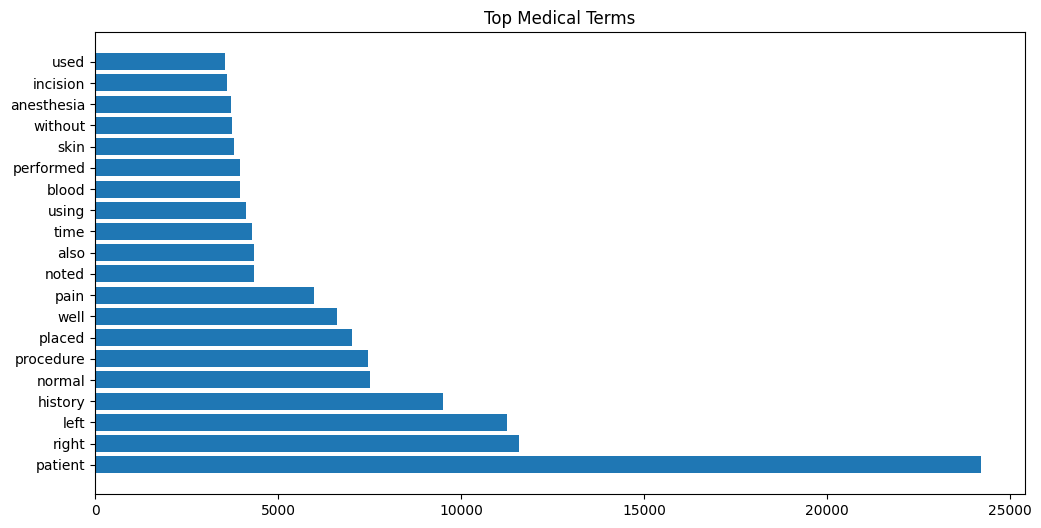

In [41]:
import matplotlib.pyplot as plt

top20 = medical_dictionary.head(20)

plt.figure(figsize=(12,6))

plt.barh(

    top20['Medical_Term'],
    top20['Frequency']

)

plt.title(
    "Top Medical Terms"
)

plt.show()

##Baseline Model

In [42]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling1D

from tensorflow.keras.callbacks import EarlyStopping

In [43]:
df = pd.read_csv(new_p)

df = df.dropna(
    subset=[
        'transcription',
        'medical_specialty'
    ]
)

print(df.shape)

(4966, 6)


In [44]:
specialty_counts = df[
    'medical_specialty'
].value_counts()

valid_specialties = specialty_counts[
    specialty_counts >= 20
].index

df = df[
    df['medical_specialty']
    .isin(valid_specialties)
]

print(df.shape)

(4841, 6)


In [45]:
texts = df['transcription'].astype(str)

labels = df['medical_specialty']

In [46]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    labels
)

num_classes = len(
    label_encoder.classes_
)

print("Classes:", num_classes)

Classes: 29


In [47]:
with open(
    "label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(
        label_encoder,
        f
    )

In [48]:
VOCAB_SIZE = 20000
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(
    texts
)

with open(
    "tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

In [49]:
lengths = [
    len(seq)
    for seq in sequences
]

print(
    np.percentile(lengths,95)
)
MAX_LEN = 500

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)


1069.0


In [50]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [51]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    ),

    GlobalAveragePooling1D(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        num_classes,
        activation='softmax'
    )

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [52]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True

)

history = model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.2444 - loss: 2.8670 - val_accuracy: 0.3226 - val_loss: 2.6628
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3294 - loss: 2.5207 - val_accuracy: 0.3226 - val_loss: 2.5009
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3423 - loss: 2.4049 - val_accuracy: 0.3394 - val_loss: 2.4183
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3565 - loss: 2.3215 - val_accuracy: 0.3510 - val_loss: 2.3759
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3694 - loss: 2.2243 - val_accuracy: 0.3342 - val_loss: 2.3219
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3788 - loss: 2.1103 - val_accuracy: 0.3419 - val_loss: 2.2161
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3959 - loss: 1.9830 - val_accuracy: 0.3342 - val_loss: 2.1377
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4075 - loss: 1.8580 - val_accuracy: 0.3161 - val_loss

In [55]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    accuracy
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3024 - loss: 1.9808
Test Accuracy: 0.30237358808517456


In [56]:
from sklearn.metrics import classification_report

predictions = model.predict(
    X_test
)

y_pred = np.argmax(
    predictions,
    axis=1
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=
        label_encoder.classes_
    )
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.25      0.35      0.30        74
    Consult - History and Phy.       0.25      0.37      0.30       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
             Discharge Summary       0.27      0.18      0.22        22
          ENT - Otolaryngology       0.00      0.00      0.00        19
        Emergency Room Reports       0.00      0.00      0.00        15
              Gastroenterology       0.00      0.00      0.00        45
              General Medicine       0.17      0.27      0.21        52
         Hematology - Oncology       0.00      0.00      0.00        18
                       Letters       0.00      0.00      0.00         5
                    Nep

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


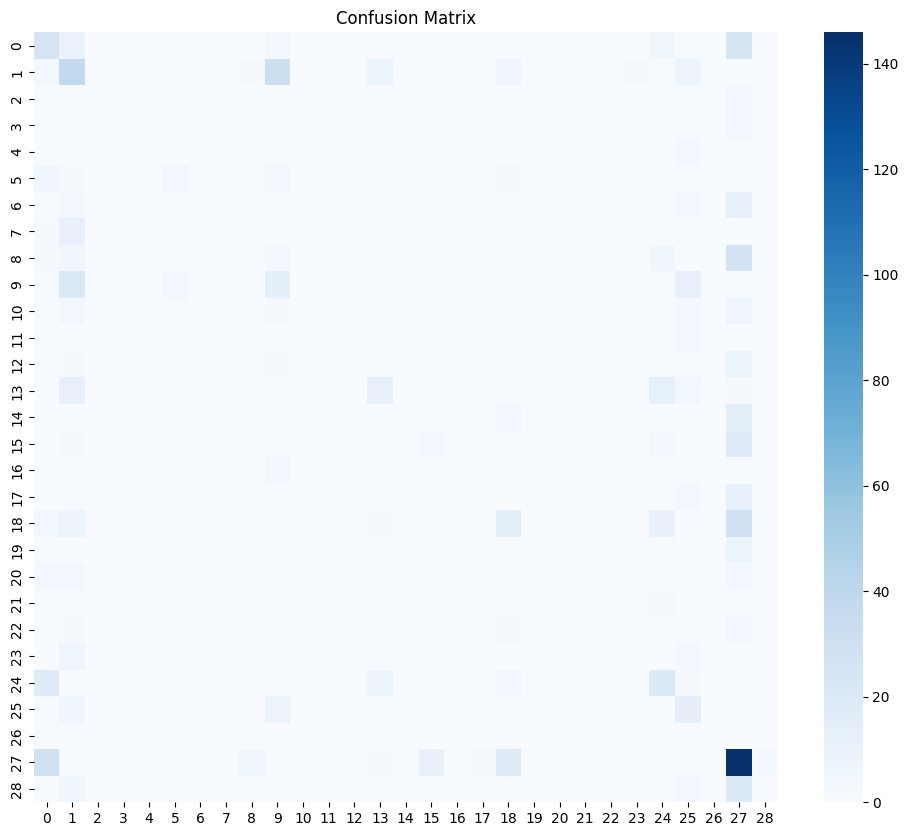

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.show()

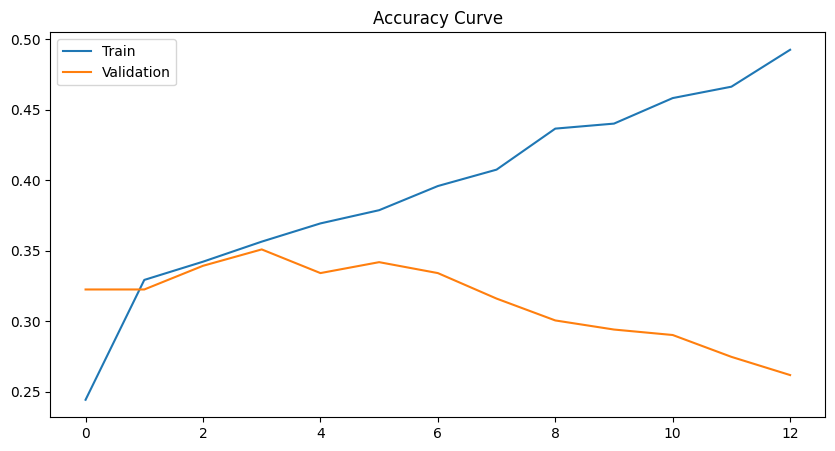

In [58]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.legend()

plt.title(
    "Accuracy Curve"
)

plt.show()

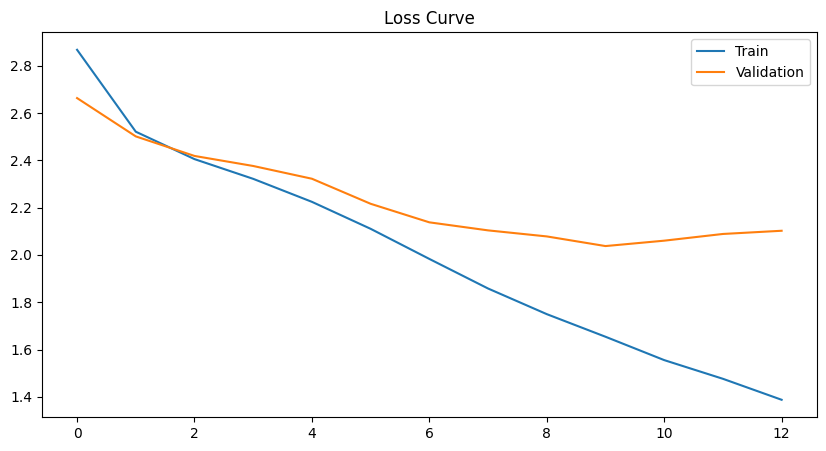

In [59]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.legend()

plt.title(
    "Loss Curve"
)

plt.show()

In [60]:
model.save(
    "baseline_model.keras"
)

In [61]:
def predict_specialty(text):

    seq = tokenizer.texts_to_sequences(
        [text]
    )

    seq = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post'
    )

    pred = model.predict(seq)

    idx = np.argmax(pred)

    specialty = label_encoder.inverse_transform(
        [idx]
    )[0]

    confidence = np.max(pred)

    return specialty, confidence

In [62]:
text = """
Patient presents with chest pain,
coronary artery disease,
and abnormal ECG findings.
"""

specialty, confidence = predict_specialty(text)

print(specialty)
print(confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
 Cardiovascular / Pulmonary
0.26188043


##Self Attention Model

In [63]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model

In [64]:
import tensorflow as tf
import numpy as np

class PositionalEncoding(tf.keras.layers.Layer):

    def __init__(self, max_len, d_model):
        super().__init__()

        pos = np.arange(max_len)[:, np.newaxis]

        i = np.arange(d_model)[np.newaxis, :]

        angle_rates = 1 / np.power(
            10000,
            (2 * (i // 2)) / d_model
        )

        angle_rads = pos * angle_rates

        angle_rads[:, 0::2] = np.sin(
            angle_rads[:, 0::2]
        )

        angle_rads[:, 1::2] = np.cos(
            angle_rads[:, 1::2]
        )

        self.pos_encoding = tf.cast(
            angle_rads[np.newaxis, ...],
            dtype=tf.float32
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        return x + self.pos_encoding[:, :seq_len, :]

In [65]:
VOCAB_SIZE = 20000

MAX_LEN = 500

EMBED_DIM = 128

NUM_HEADS = 4

DENSE_UNITS = 128

In [66]:
inputs = Input(shape=(MAX_LEN,))

x = Embedding(
    VOCAB_SIZE,
    EMBED_DIM
)(inputs)

x = PositionalEncoding(
    MAX_LEN,
    EMBED_DIM
)(x)

attn = MultiHeadAttention(
    num_heads=NUM_HEADS,
    key_dim=EMBED_DIM
)(x, x)

x = x + attn

x = LayerNormalization()(x)

# IMPORTANT
x = GlobalAveragePooling1D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    num_classes,
    activation='softmax'
)(x)

attention_model = Model(
    inputs,
    outputs
)

In [67]:
attention_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [68]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=3,

    restore_best_weights=True

)

history_attention = attention_model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=15,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.2144 - loss: 2.9227 - val_accuracy: 0.3303 - val_loss: 2.7312
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.3190 - loss: 2.6208 - val_accuracy: 0.3381 - val_loss: 2.5021
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3455 - loss: 2.4777 - val_accuracy: 0.3406 - val_loss: 2.4403
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3581 - loss: 2.3599 - val_accuracy: 0.3406 - val_loss: 2.3700
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3704 - loss: 2.1693 - val_accuracy: 0.3381 - val_loss: 2.2830
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3788 - loss: 2.0011 - val_accuracy: 0.3019 - val_loss: 2.3020
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4065 - loss: 1.7782 - val_accuracy: 0.2606 - val_loss: 2.3286
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4256 - loss: 1.6673 - val_accuracy: 0.2658 - 

In [69]:
loss, accuracy = attention_model.evaluate(
    X_test,
    y_test
)

print(
    "Attention Model Accuracy:",
    accuracy
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.3591 - loss: 2.2240
Attention Model Accuracy: 0.35913312435150146


In [70]:
from sklearn.metrics import classification_report
import numpy as np

pred_probs = attention_model.predict(
    X_test
)

preds = np.argmax(
    pred_probs,
    axis=1
)

print(
    classification_report(
        y_test,
        preds,
        target_names=
        label_encoder.classes_
    )
)

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.32      0.08      0.13        74
    Consult - History and Phy.       0.27      0.84      0.41       103
    Cosmetic / Plastic Surgery       0.00      0.00      0.00         5
                     Dentistry       0.00      0.00      0.00         5
                   Dermatology       0.00      0.00      0.00         6
             Discharge Summary       0.00      0.00      0.00        22
          ENT - Otolaryngology       0.00      0.00      0.00        19
        Emergency Room Reports       0.00      0.00      0.00        15
              Gastroenterology       0.00      0.00      0.00        45
              General Medicine       0.00      0.00      0.00        52
         Hematology - Oncology       0.00      0.00      0.00        18
                       Letters       0.00      0.00      0.00         5
                    Nep

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


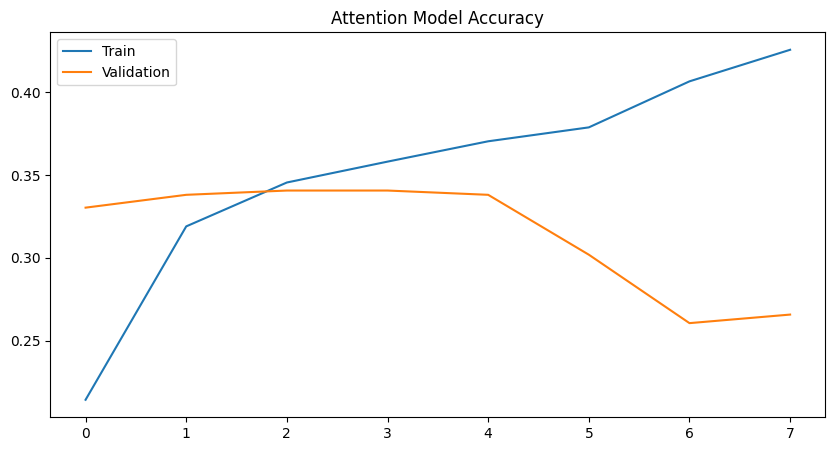

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_attention.history['accuracy'],
    label='Train'
)

plt.plot(
    history_attention.history['val_accuracy'],
    label='Validation'
)

plt.legend()

plt.title(
    "Attention Model Accuracy"
)

plt.show()

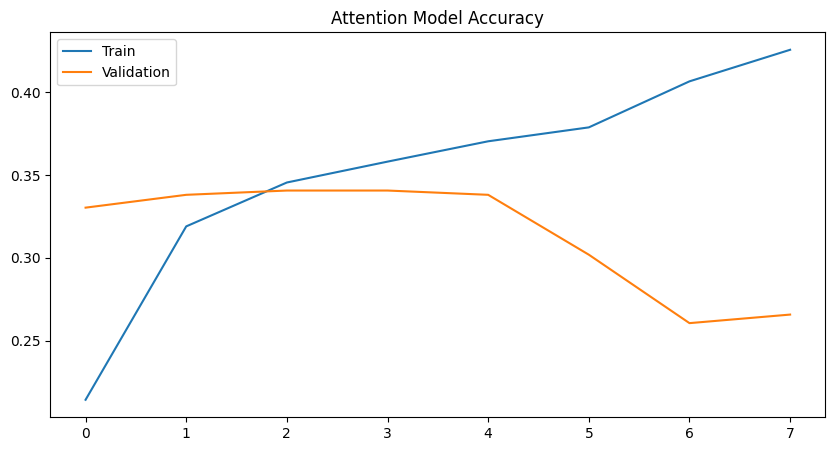

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    history_attention.history['accuracy'],
    label='Train'
)

plt.plot(
    history_attention.history['val_accuracy'],
    label='Validation'
)

plt.legend()

plt.title(
    "Attention Model Accuracy"
)

plt.show()

In [73]:
attention_model.save(
    "attention_model.keras"
)

In [74]:
def predict_attention(text):

    seq = tokenizer.texts_to_sequences(
        [text]
    )

    seq = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post'
    )

    pred = attention_model.predict(seq)

    idx = np.argmax(pred)

    specialty = label_encoder.inverse_transform(
        [idx]
    )[0]

    confidence = np.max(pred)

    return specialty, confidence

In [75]:
text = """
MRI demonstrates acute infarction
in the left parietal lobe
consistent with ischemic stroke.
"""

specialty, conf = predict_attention(text)

print(specialty)
print(conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
 Radiology
0.31549692


##Positional Encoding

In [76]:
import numpy as np

def positional_encoding(max_position, d_model):

    PE = np.zeros((max_position, d_model))

    for pos in range(max_position):

        for i in range(d_model):

            angle = pos / np.power(
                10000,
                (2 * (i // 2)) / d_model
            )

            if i % 2 == 0:
                PE[pos, i] = np.sin(angle)
            else:
                PE[pos, i] = np.cos(angle)

    return PE

In [77]:
MAX_LEN = 100
EMBED_DIM = 128

pe = positional_encoding(
    MAX_LEN,
    EMBED_DIM
)

print(pe.shape)

(100, 128)


In [78]:
print(pe[:5, :10])

[[ 0.          1.          0.          1.          0.          1.
   0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.76172041  0.64790587  0.68156135  0.73176098
   0.60469402  0.79645787  0.53316844  0.84600911]
 [ 0.90929743 -0.41614684  0.98704625 -0.16043596  0.99748     0.07094825
   0.96322662  0.26869029  0.90213071  0.43146283]
 [ 0.14112001 -0.9899925   0.51730572 -0.85580068  0.77827252 -0.62792665
   0.92964484 -0.36845688  0.99325317 -0.11596614]
 [-0.7568025  -0.65364362 -0.31671543 -0.9485206   0.14153892 -0.98993269
   0.51761928 -0.85561105  0.77847174 -0.62767965]]


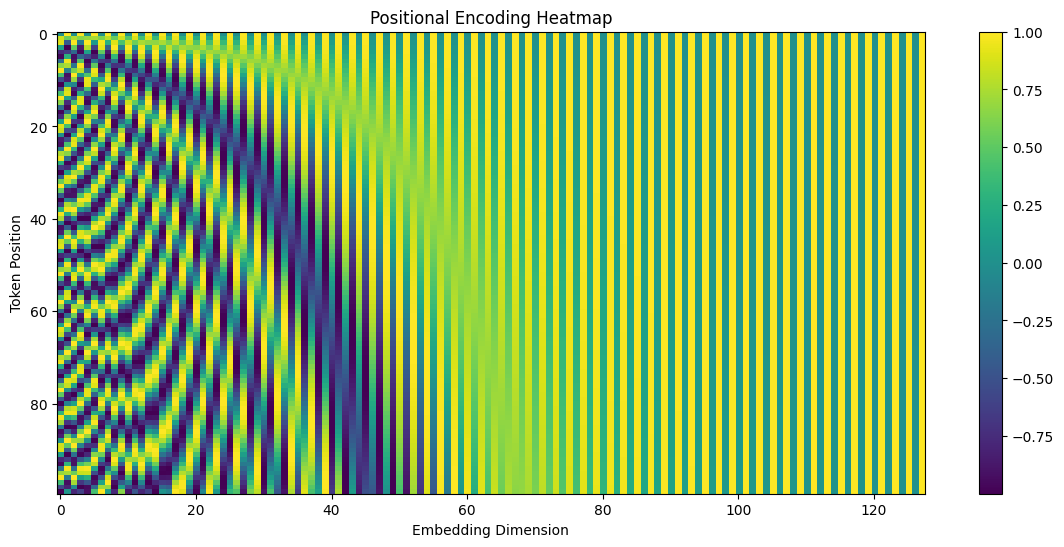

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.imshow(
    pe,
    aspect='auto'
)

plt.colorbar()

plt.xlabel("Embedding Dimension")
plt.ylabel("Token Position")

plt.title(
    "Positional Encoding Heatmap"
)

plt.show()

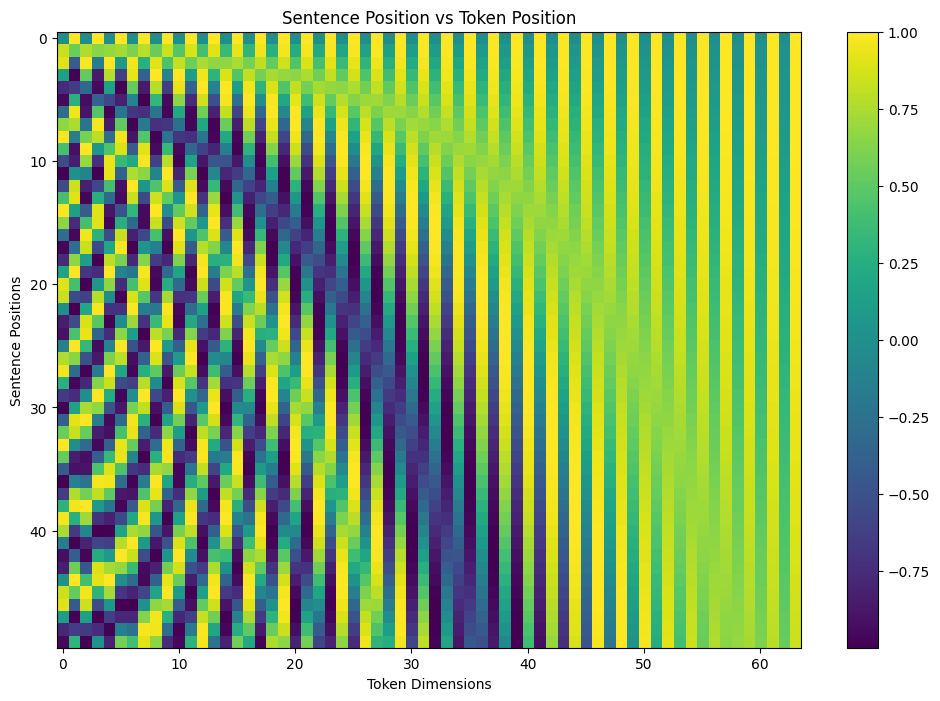

In [80]:
plt.figure(figsize=(12,8))

plt.imshow(
    pe[:50, :64],
    aspect='auto'
)

plt.colorbar()

plt.xlabel("Token Dimensions")
plt.ylabel("Sentence Positions")

plt.title(
    "Sentence Position vs Token Position"
)

plt.show()

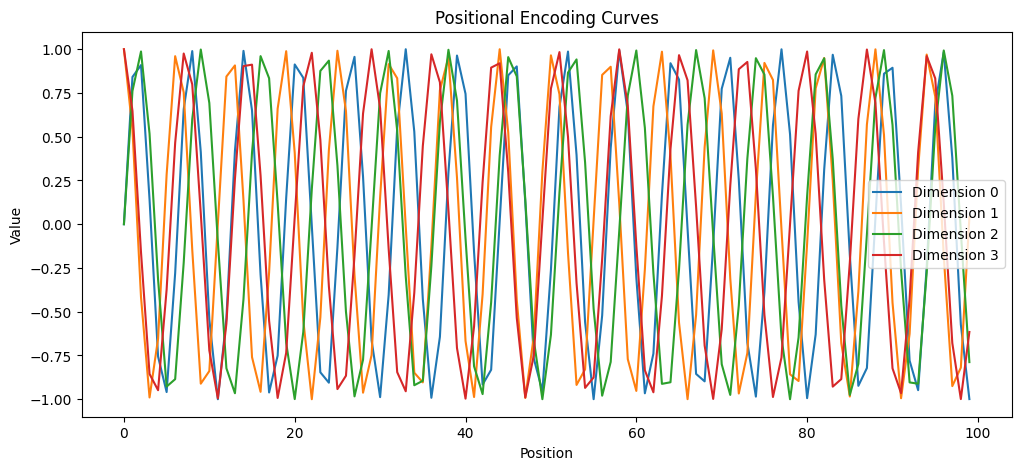

In [81]:
plt.figure(figsize=(12,5))

plt.plot(pe[:,0], label='Dimension 0')
plt.plot(pe[:,1], label='Dimension 1')
plt.plot(pe[:,2], label='Dimension 2')
plt.plot(pe[:,3], label='Dimension 3')

plt.legend()

plt.title(
    "Positional Encoding Curves"
)

plt.xlabel("Position")
plt.ylabel("Value")

plt.show()

In [82]:
sentence1 = [
    "brain",
    "tumor",
    "detected"
]

sentence2 = [
    "detected",
    "tumor",
    "brain"
]

In [83]:
np.random.seed(42)

embeddings = np.random.rand(
    3,
    128
)

In [84]:
import tensorflow as tf

class PositionalEncoding(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        max_len,
        d_model
    ):
        super().__init__()

        self.pos_encoding = positional_encoding(
            max_len,
            d_model
        )

        self.pos_encoding = tf.cast(
            self.pos_encoding,
            tf.float32
        )

    def call(self, x):

        seq_len = tf.shape(x)[1]

        return (
            x +
            self.pos_encoding[
                :seq_len
            ]
        )

In [85]:
np.save(
    "positional_encoding.npy",
    pe
)

##Diagnostic Importance Analysis

In [93]:
attention_layer = tf.keras.layers.MultiHeadAttention(
    num_heads=4,
    key_dim=128
)

attn_output, attn_scores = attention_layer(
    x,
    x,
    return_attention_scores=True
)

In [94]:
inputs = attention_model.input

embedding_output = attention_model.layers[1].output

In [99]:
import tensorflow as tf

class ExplainableMedicalModel(tf.keras.Model):

    def __init__(self,
                 vocab_size,
                 embed_dim,
                 num_heads,
                 num_classes):

        super().__init__()

        self.embedding = tf.keras.layers.Embedding(
            vocab_size,
            embed_dim
        )

        self.position = PositionalEncoding(
            MAX_LEN,
            embed_dim
        )

        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.pool = tf.keras.layers.GlobalAveragePooling1D()

        self.fc = tf.keras.layers.Dense(
            128,
            activation='relu'
        )

        self.output_layer = tf.keras.layers.Dense(
            num_classes,
            activation='softmax'
        )

    def call(self, x, return_scores=False):

        x = self.embedding(x)

        x = self.position(x)

        attn_output, attn_scores = self.attention(
            x,
            x,
            return_attention_scores=True
        )

        x = self.pool(attn_output)

        x = self.fc(x)

        preds = self.output_layer(x)

        if return_scores:
            return preds, attn_scores

        return preds

In [100]:
explainable_model = ExplainableMedicalModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    num_heads=4,
    num_classes=num_classes
)

In [101]:
sample_text = """
MRI demonstrates acute ischemic stroke
in the left hemisphere.
"""

In [102]:
seq = tokenizer.texts_to_sequences(
    [sample_text]
)

seq = pad_sequences(
    seq,
    maxlen=MAX_LEN
)

In [103]:
preds, scores = explainable_model(
    seq,
    return_scores=True
)

In [104]:
print(scores.shape)

(1, 4, 100, 100)


In [105]:
import numpy as np

scores = scores.numpy()

mean_scores = np.mean(
    scores,
    axis=1
)

In [106]:
token_importance = mean_scores[0].mean(
    axis=0
)

In [107]:
token_importance.shape

(100,)

In [108]:
tokens = seq[0]

In [109]:
index_word = tokenizer.index_word

In [110]:
words = []

for token in tokens:

    if token == 0:
        continue

    words.append(
        index_word.get(
            token,
            "<UNK>"
        )
    )

In [111]:
importance_df = pd.DataFrame({

    "Word": words,

    "Importance":
        token_importance[:len(words)]

})

In [112]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

In [113]:
print(
    importance_df.head(15)
)

           Word  Importance
3      ischemic    0.010028
2         acute    0.010026
4        stroke    0.010025
1  demonstrates    0.010022
0           mri    0.010019
5            in    0.010018
8    hemisphere    0.010012
6           the    0.010011
7          left    0.010009


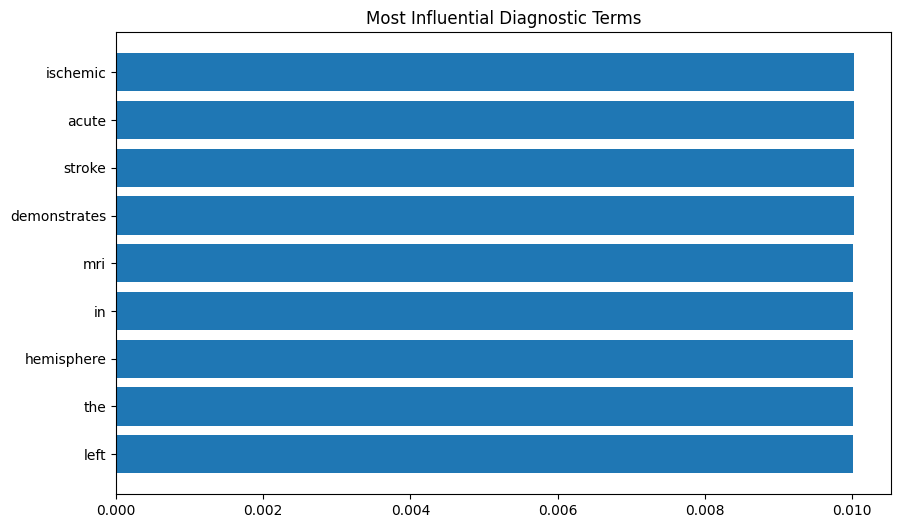

In [114]:
import matplotlib.pyplot as plt

top_words = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(

    top_words['Word'],

    top_words['Importance']

)

plt.title(
    "Most Influential Diagnostic Terms"
)

plt.gca().invert_yaxis()

plt.show()

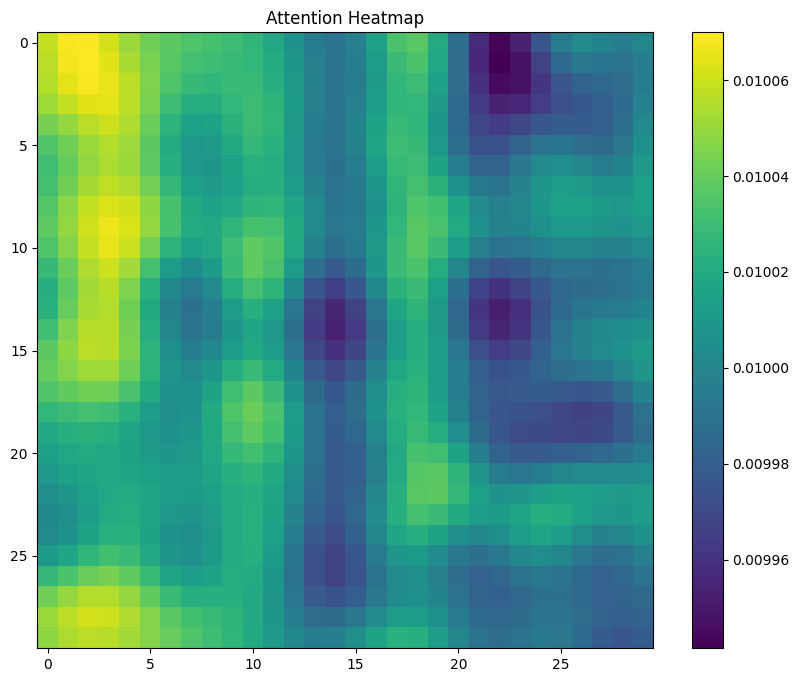

In [115]:
plt.figure(figsize=(10,8))

plt.imshow(
    mean_scores[0][:30,:30]
)

plt.colorbar()

plt.title(
    "Attention Heatmap"
)

plt.show()

In [116]:
def explain_prediction(text):

    seq = tokenizer.texts_to_sequences(
        [text]
    )

    seq = pad_sequences(
        seq,
        maxlen=MAX_LEN
    )

    pred, scores = explainable_model(
        seq,
        return_scores=True
    )

    pred_class = np.argmax(
        pred.numpy()
    )

    specialty = label_encoder.inverse_transform(
        [pred_class]
    )[0]

    confidence = np.max(
        pred.numpy()
    )

    return specialty, confidence

In [117]:
importance_df.to_csv(
    "diagnostic_importance.csv",
    index=False
)

In [121]:
explainable_model.export(
    "explainable_model"
)

Saved artifact at 'explainable_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)
Captures:
  133865011942352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007795856: TensorSpec(shape=(100, 128), dtype=tf.float32, name=None)
  133865007792976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007798736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007795664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007796432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007797392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007796816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007797776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007800848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133865007797968: Tensor

In [122]:
import shutil

# Syntax: shutil.make_archive('output_zip_name', 'zip', 'folder_to_zip')
shutil.make_archive('/content/explainable_model', 'zip', '/content/explainable_model')


'/content/explainable_model.zip'